--- System Transfer Function ---
<TransferFunction>: sys[3]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              s + 1
  -----------------------------
  s^4 + 4 s^3 + 7 s^2 + 6 s + 3


c:\Users\man\AppData\Local\Programs\Python\Python313\Lib\site-packages\control\pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


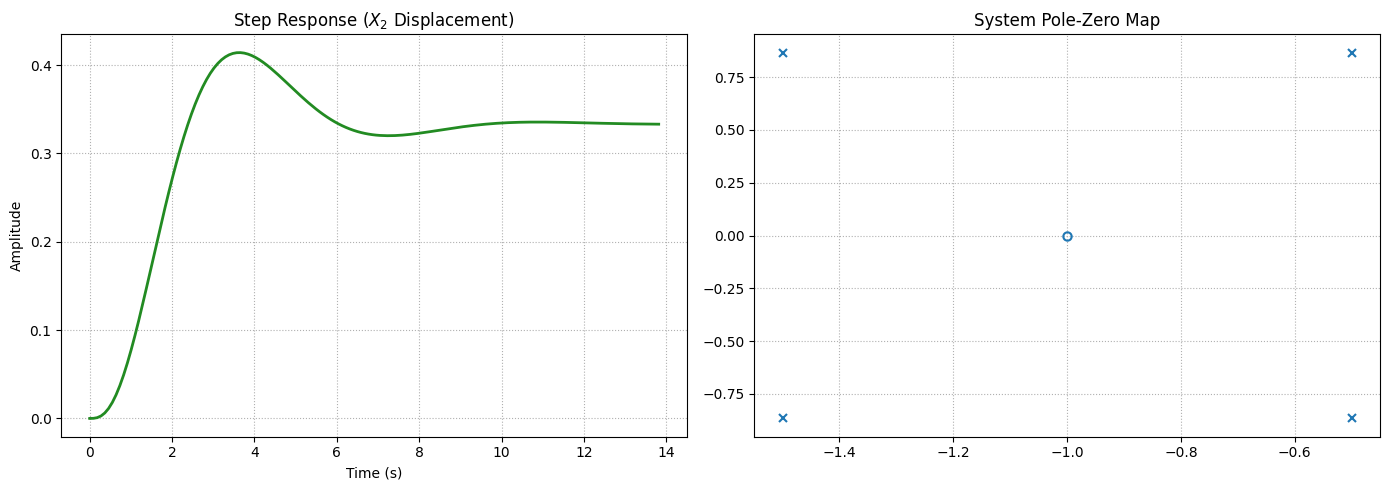

In [2]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

def generate_control_analysis():
    # Define the polynomials from the derivation
    # P1 = (s^2 + 2s + 2)
    p1 = np.poly1d([1, 2, 2])
    # P2 = (s + 1)
    p2 = np.poly1d([1, 1])
    
    # Numerator is (s + 1)
    numerator = p2.coeffs
    
    # Denominator is (p1 * p1) - (p2 * p2)
    denominator_poly = (p1 * p1) - (p2 * p2)
    denominator = denominator_poly.coeffs
    
    # Create the Transfer Function object
    sys = ct.TransferFunction(numerator, denominator)
    
    print("--- System Transfer Function ---")
    print(sys)
    
    # Plotting setup
    fig, (ax_step, ax_pz) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Step Response
    t, y = ct.step_response(sys)
    ax_step.plot(t, y, color='forestgreen', linewidth=2)
    ax_step.set_title('Step Response ($X_2$ Displacement)')
    ax_step.set_xlabel('Time (s)')
    ax_step.set_ylabel('Amplitude')
    ax_step.grid(True, linestyle=':')
    
    # 2. Pole-Zero Map
    ct.pzmap(sys, plot=True, ax=ax_pz)
    ax_pz.set_title('System Pole-Zero Map')
    ax_pz.grid(True, linestyle=':')
    
    plt.tight_layout()
    plt.show()

# Run the analysis
generate_control_analysis()